## Домашка 1
#### *«Великаны — как луковицы. Лук многослоен! Я тоже! Слой за слоем. Ты усёк? Мы многослойные!» — Шрек*

Эта домашка про декомпозицию и срезы. За неё можно получить максимум 6 баллов.

**Дедлайны**  
Мягкий дедлайн: 20.09.2026 23:59 по МСК.   
Жесткий дедлайн: 27.09.2026 23:59 по МСК.  

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.   
После жесткого дедлайна работы не принимаются.   

**Правила сдачи**   
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.    

**Использование ИИ**
- Использование генеративных моделей для написания кода допустимо при следующих условиях: сгенерированный фрагмент прочитан, адаптирован под условие задачи и данные, вы способны объяснить каждую его строку. Решение, полученное путем передачи модели формулировки задания целиком и прямого копирования ответа в ячейку ноутбука без содержательной переработки, оценивается в 0 баллов за это задание.
- Ответы на текстовые вопросы (описание поведения графика, интерпретация метрики, формулировка гипотез и т.п.) должны быть написаны вами самостоятельно в markdown-ячейках. Использование генеративных моделей для ответа на текстовые вопросы приводит к аннулированию всей работы, а не отдельного задания: интерпретация результатов — главный проверяемый в курсе навык, передача ее ИИ лишает нас возможности оценить, насколько хорошо вы усвоили материал.
- Если генеративная модель использовалась при решении, в конце ноутбука в отдельной markdown-ячейке укажите: номера заданий, при работе над которыми она применялась, использованную модель (с версией) и текст промтов. При обоснованном подозрении на использование ИИ, не отраженное в этом разделе, работа аннулируется целиком независимо от того, к какой части заданий относится подозрение.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета.
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_1). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3.

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_1_data.zip)

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

### Case Study. Что-то пошло не так в маркетплейсе 🛒

**Легенда**  
Вы работаете продуктовым аналитиком в маркетплейсе. Ваша команда отвечает за функционал корзины — точки входа, дизайн и функционал самой корзины, путь пользователя с момента добавления товара в корзину и до оформления покупки.

Компания — стартап без системы автоматического мониторинга. Поэтому последние 14 дней, пока вы были в отпуске, никто не следил за метриками корзины.

Вы отлично отдохнули и в первый же день после каникул рвётесь в бой. Наливаете чашку кофе, открываете ноутбук и проверяете, что творилось в ваше отсутствие.

In [4]:
df = pd.read_parquet('data/hw_1_marketplace_data.parquet')

In [5]:
df.head()

,user_id,session_id,event_ts,platform,app_version,region,channel,category,event,product_id,price,quantity
0,30,1094418511,2025-04-01 19:49:57,Desktop,web,siberia,ads_search,None,search,NaN,NaN,NaN
1,30,1094418511,2025-04-01 20:02:23,Desktop,web,siberia,ads_search,electronics,view_item,123443.0,NaN,NaN
2,30,1094418511,2025-04-01 20:22:53,Desktop,web,siberia,ads_search,fashion,view_item,162950.0,NaN,NaN
3,30,1094418511,2025-04-01 20:40:57,Desktop,web,siberia,ads_search,home,view_item,199979.0,NaN,NaN
4,30,1094418511,2025-04-01 20:41:07,Desktop,web,siberia,ads_search,home,add_to_cart,199979.0,NaN,NaN


Описание данных

- user_id — уникальный идентификатор пользователя
- session_id — уникальный идентификатор сессии
- event_ts — таймстемп событий
- platform — платформа, с которой пришло событие
- app_version — версия приложения (существует только для iOS и Android, для остальных платформ приходят значения-заглушки)
- region — регион пользователя
- channel — канал, с которого пришел пользователь
- category — категория товаров, которой принадлежит ивент
- event — событие, совершенное пользователем
- product_id — идентификатор товара для событий над товарами
- price — цена товара, ивент приходит только для события покупки
- quantity — количество товаров, ивент приходит только для события покупки

#### **1. Детекция проблемы — 1 балл**

1) Посчитайте подневные конверсии: из просмотра в покупку, из просмотра в добавление в корзину, из добавления в корзину — в покупку.
2) Визуализируйте полученную динамику.
3) Опишите, что вы видите на графике: когда и в каких метриках началось падение? есть ли устойчивый тренд?

*К подсчёту конверсий можно подойти разными способами — считать их по событиям, сессиям или уникальным юзерам. В нашей задаче будем считать по сессиям.*

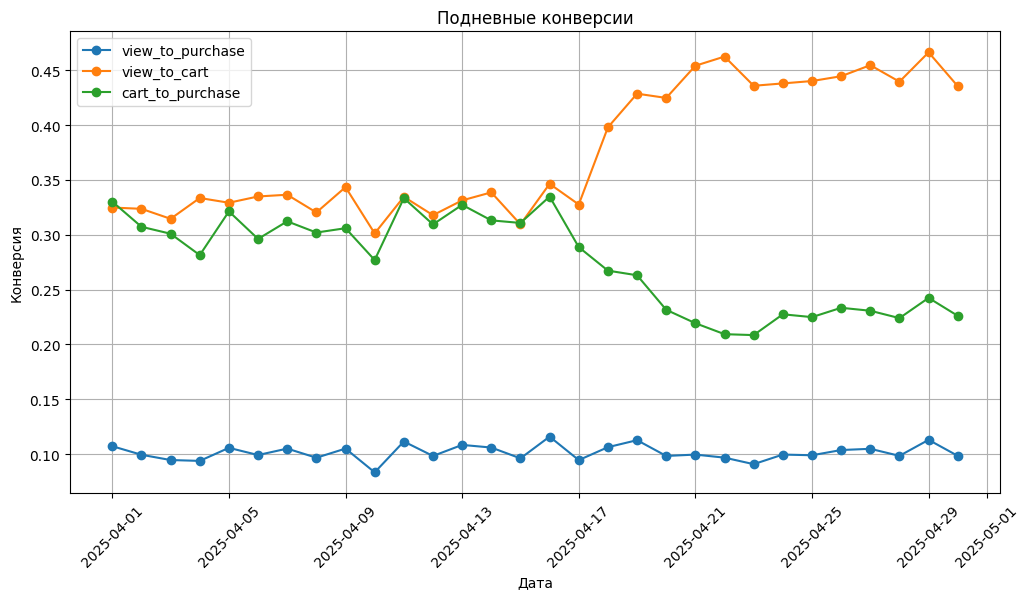

In [6]:
df['date'] = df['event_ts'].dt.date

view_sessions = df[df['event'] == 'view_item'].groupby('date')['session_id'].nunique()
cart_sessions = df[df['event'] == 'add_to_cart'].groupby('date')['session_id'].nunique()
purchase_sessions = df[df['event'] == 'purchase'].groupby('date')['session_id'].nunique()

conversions = pd.DataFrame({
    'view_to_purchase': purchase_sessions / view_sessions,
    'view_to_cart': cart_sessions / view_sessions,
    'cart_to_purchase': purchase_sessions / cart_sessions
})

conversions.plot(figsize=(12, 6), marker='o')
plt.title('Подневные конверсии')
plt.xlabel('Дата')
plt.ylabel('Конверсия')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

#### **2. Проверка абсолютных и средних значений — 1 балл**

1) Постройте графики дневной динамики абсолютных значений, из которых рассчитаны конверсии выше.
2) Рассчитайте и визуализируйте среднее число событий (именно событий, не сессий), из которых рассчитаны конверсии, на пользователя.
3) На каком этапе воронки появилась проблема?

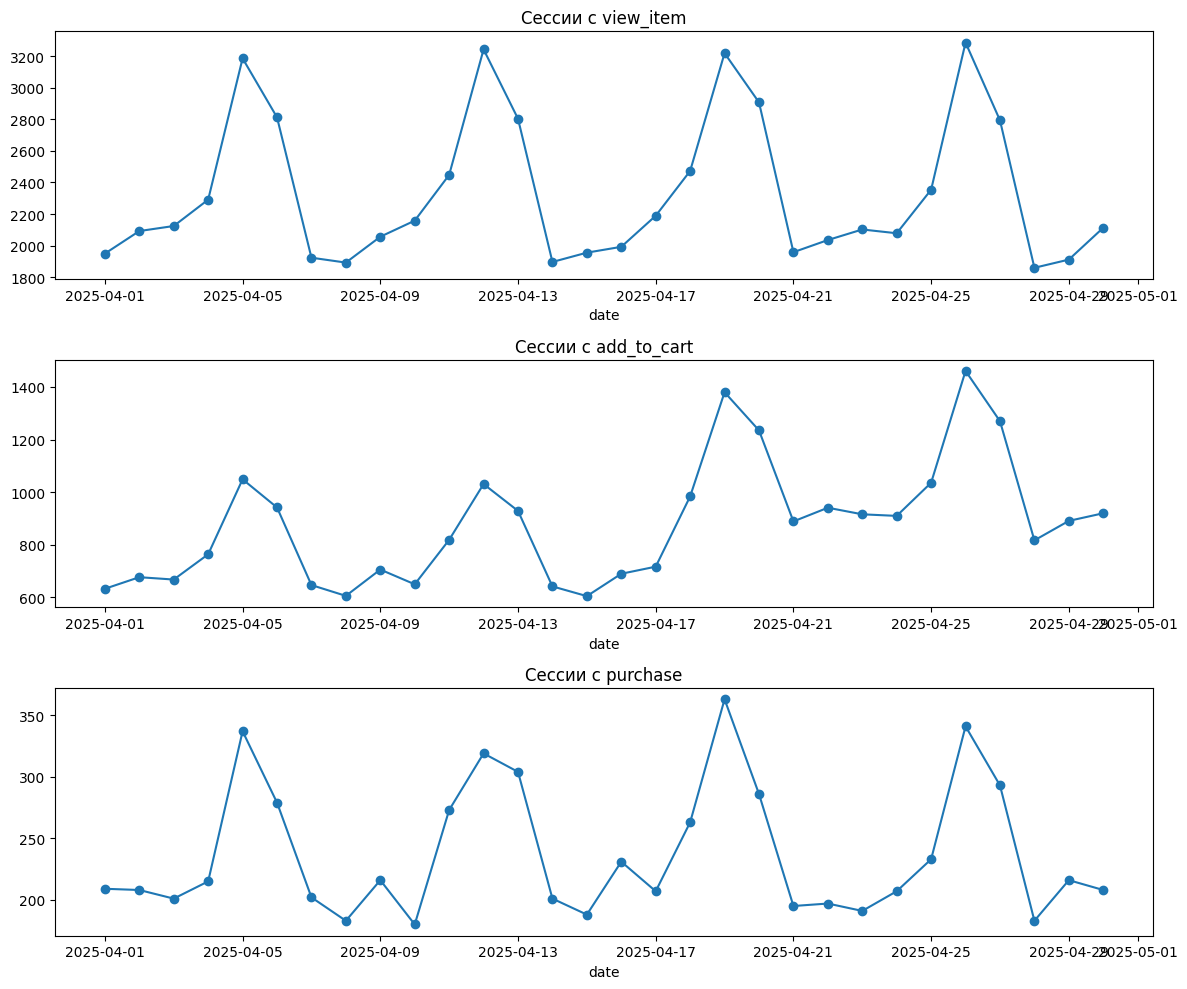

In [7]:
view_sessions = df[df['event'] == 'view_item'].groupby('date')['session_id'].nunique()
cart_sessions = df[df['event'] == 'add_to_cart'].groupby('date')['session_id'].nunique()
purchase_sessions = df[df['event'] == 'purchase'].groupby('date')['session_id'].nunique()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
view_sessions.plot(ax=axes[0], marker='o', title='Сессии с view_item')
cart_sessions.plot(ax=axes[1], marker='o', title='Сессии с add_to_cart')
purchase_sessions.plot(ax=axes[2], marker='o', title='Сессии с purchase')
plt.tight_layout()
plt.show()

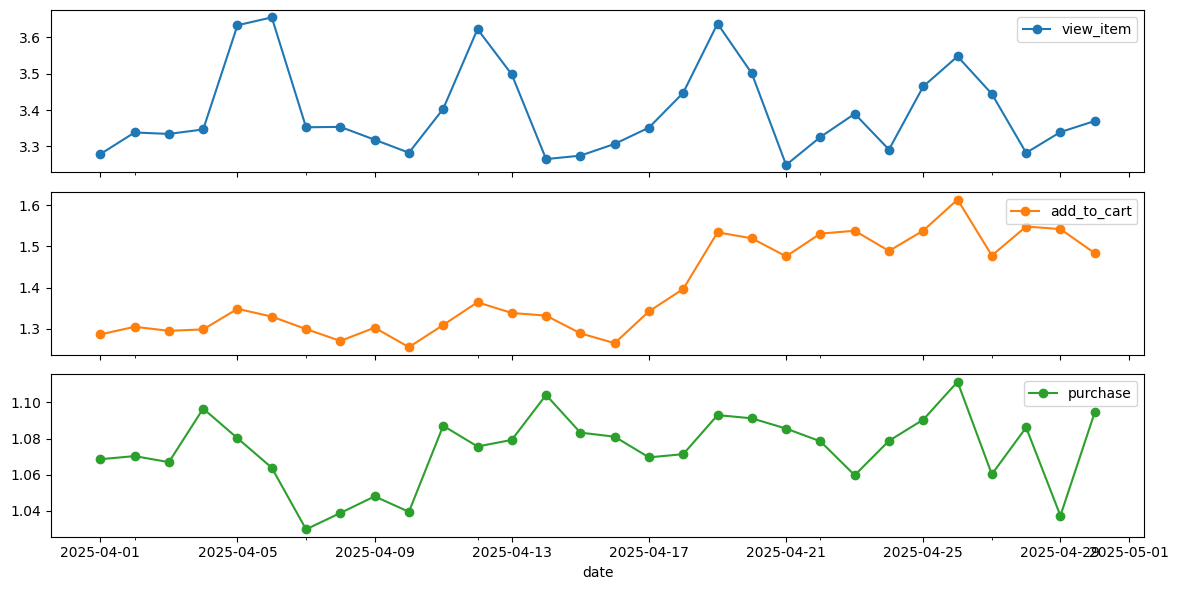

In [8]:
events_per_user = pd.DataFrame()

for ev in ['view_item', 'add_to_cart', 'purchase']:
    sub = df[df['event'] == ev]
    events_cnt = sub.groupby('date').size()
    users_cnt = sub.groupby('date')['user_id'].nunique()
    events_per_user[ev] = events_cnt / users_cnt

events_per_user.plot(figsize=(12, 6), marker='o', subplots=True)
plt.tight_layout()
plt.show()

Сессии с view_item и purchase стабильны, а сессии с add_to_cart резко растут с 18-19 апреля - как и число add_to_cart на пользователя (с ~1.3 до ~1.5), при неизменном view_item и purchase на пользователя. Проблема — именно на этапе добавления в корзину, похоже на баг с дублирующимися кликами по кнопке.

#### **3. Базовые срезы — 1 балл**
1. Постройте динамику события, среднее значение которого подскочило, в разрезе:
- платформ,
- регионов,
- источников трафика,
- категорий товаров.

2. Есть ли выделяющийся срез?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

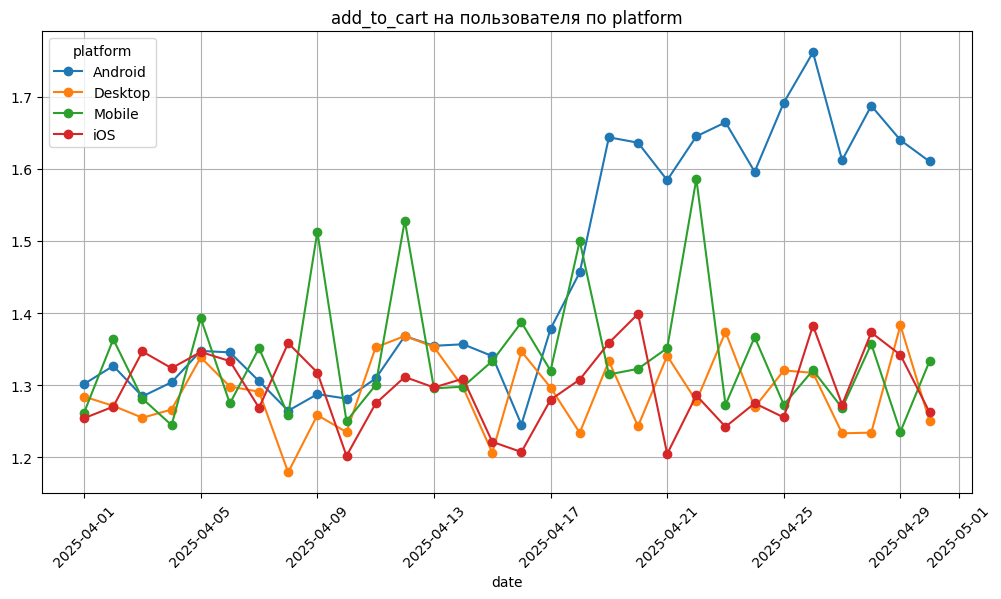

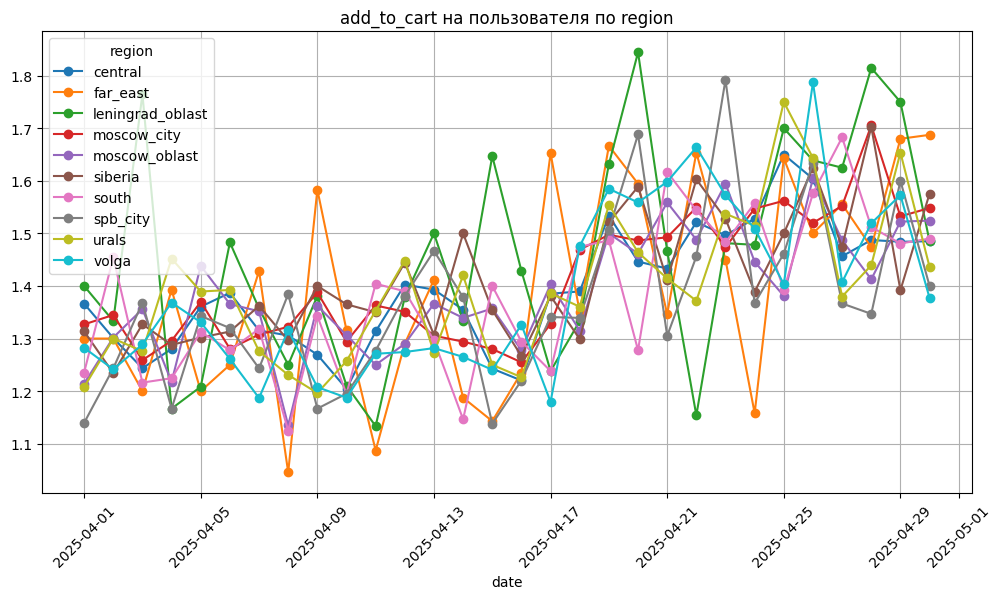

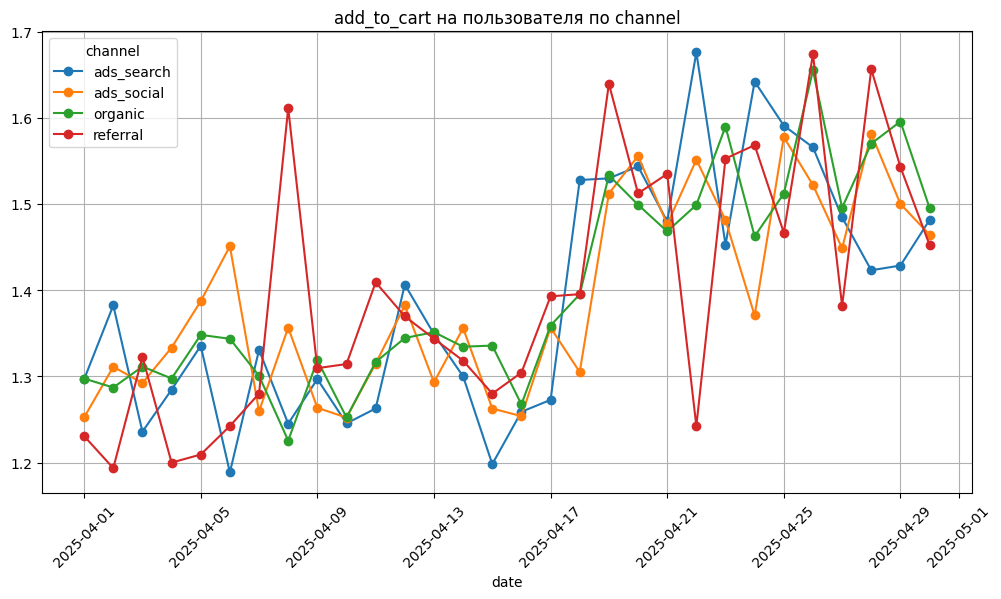

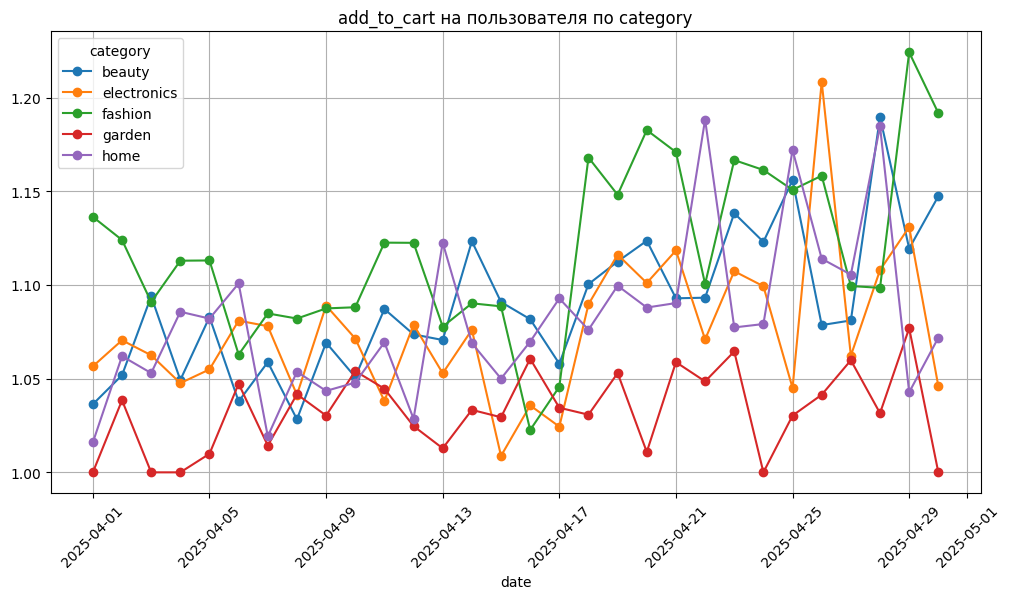

In [9]:
event_users = df[df['event'] == 'add_to_cart']

for col in ['platform', 'region', 'channel', 'category']:
    events = event_users.groupby(['date', col]).size()
    users = event_users.groupby(['date', col])['user_id'].nunique()
    ratio = (events / users).unstack()

    ratio.plot(figsize=(12, 6), marker='o', title=f'add_to_cart на пользователя по {col}')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

Явно выделяется срез по платформе - на Android число add_to_cart на пользователя растёт сильнее и заметнее остальных (с ~1.2-1.3 до ~1.6-1.8), тогда как Desktop, Mobile и iOS растут слабее и остаются в диапазоне ~1.2-1.4. По регионам, каналам и категориям выраженного выброса нет — рост распределён более-менее равномерно по всем срезам. Похоже, проблема связана с Android-приложением.

#### **4. Детальные срезы — 1 балл**
1. Постройте динамику события для iOS и Android с разложением по версиям приложения.
2. Помогло ли это локализовать проблему?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

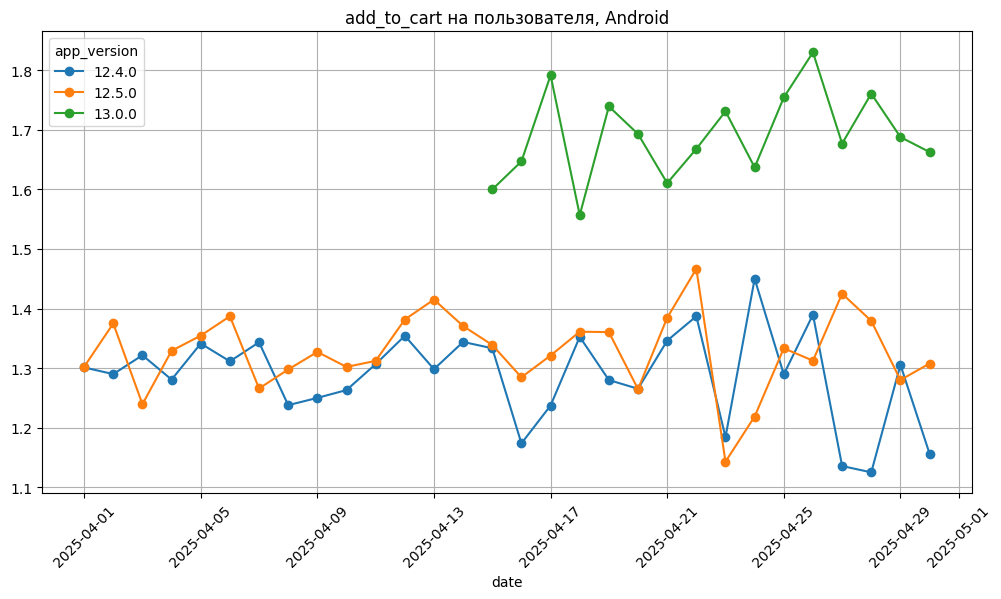

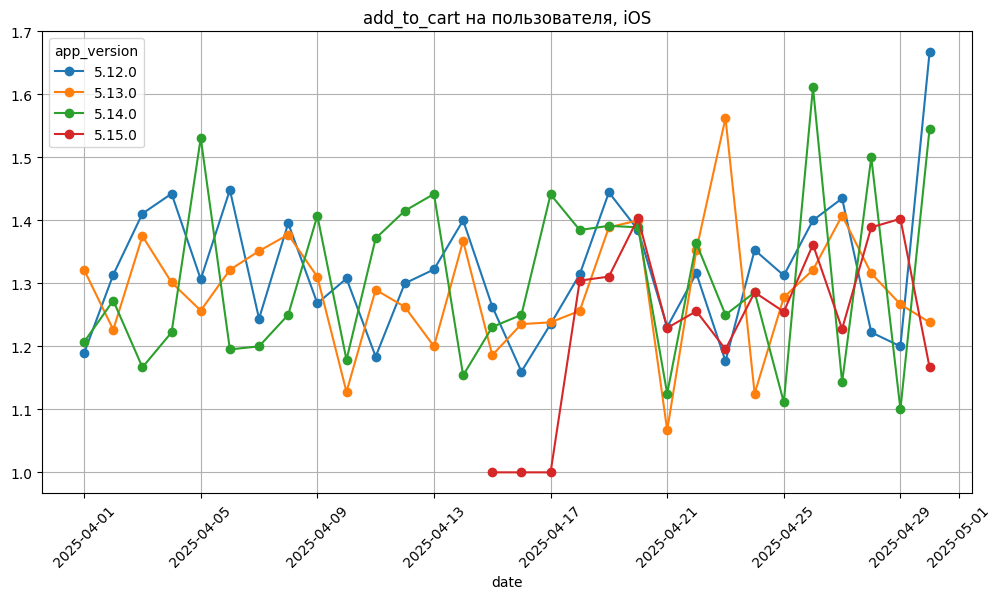

In [10]:
event_users = df[(df['event'] == 'add_to_cart') & (df['platform'].isin(['Android', 'iOS']))]

for plat in ['Android', 'iOS']:
    sub = event_users[event_users['platform'] == plat]
    events = sub.groupby(['date', 'app_version']).size()
    users = sub.groupby(['date', 'app_version'])['user_id'].nunique()
    ratio = (events / users).unstack()

    ratio.plot(figsize=(12, 6), marker='o', title=f'add_to_cart на пользователя, {plat}')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

Да, помогло локализовать проблему. На iOS все версии ведут себя похоже, без выброса. А на Android чётко видно, что версия 13.0.0 стабильно держит значение add_to_cart на пользователя намного выше (~1.6-1.8), чем версии 12.4.0 и 12.5.0 (~1.2-1.4). Версия 13.0.0 появляется в данных с 15 апреля - примерно тогда же, когда начался рост метрики в целом. Похоже, баг находится именно в релизе 13.0.0 для Android.

#### **5. Поиск причин — 1 балл**
1. Для проблемной платформы постройте динамику ВСЕХ событий в разрезе версий приложения.
2. Сформулируйте гипотезу, что именно могло пойти не так в новом релизе? Может быть, пользователи стали заменять один функционал другим?

*В этом пункте в качестве событий продолжаем смотреть метрику среднего на пользователя*

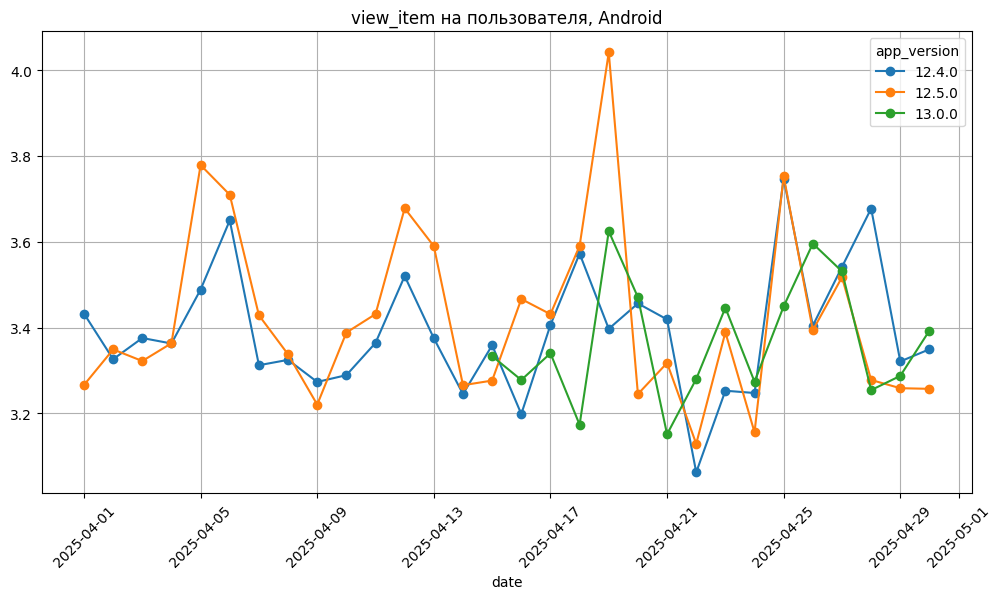

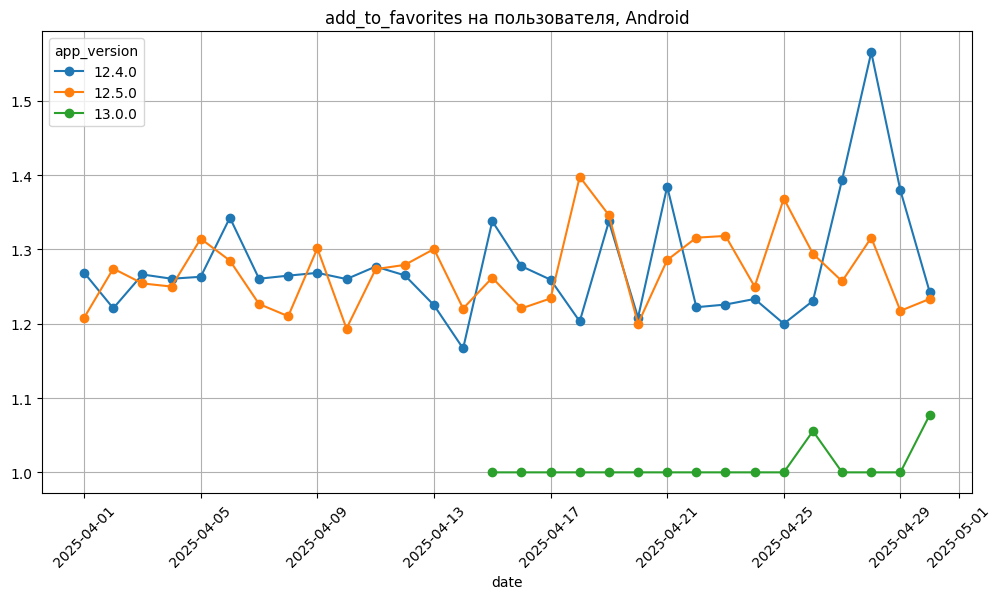

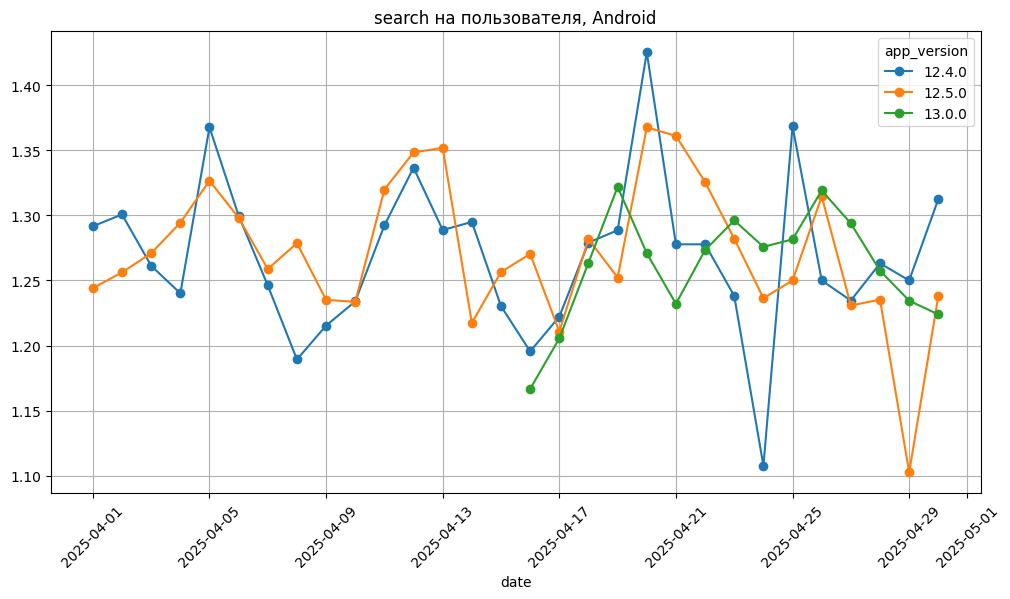

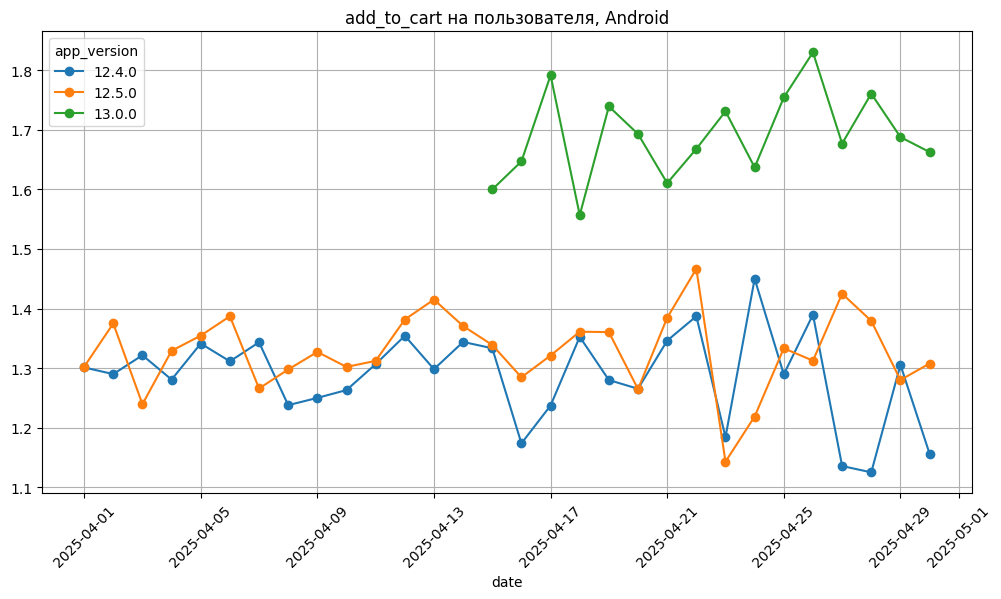

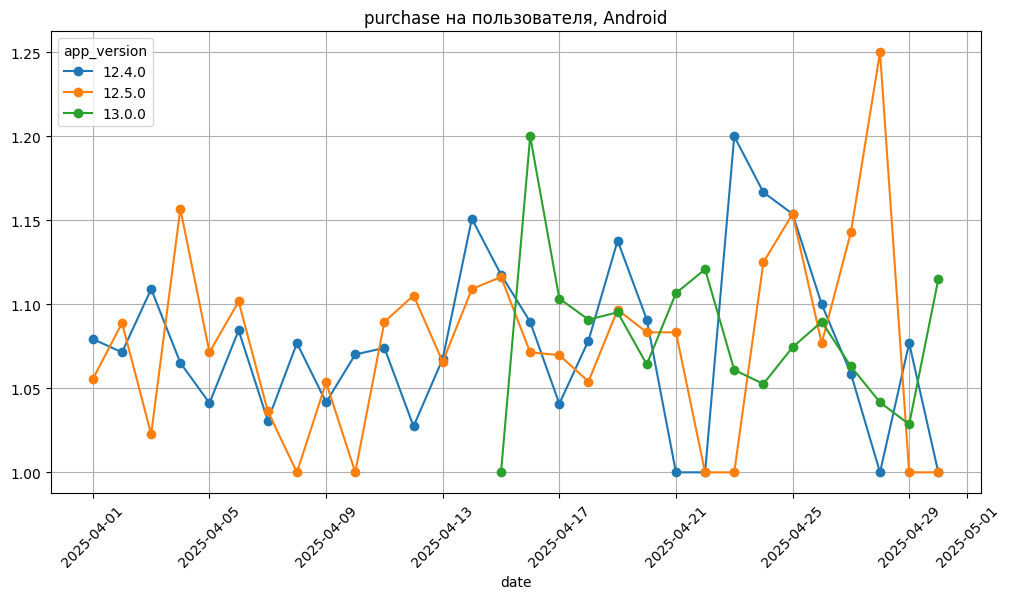

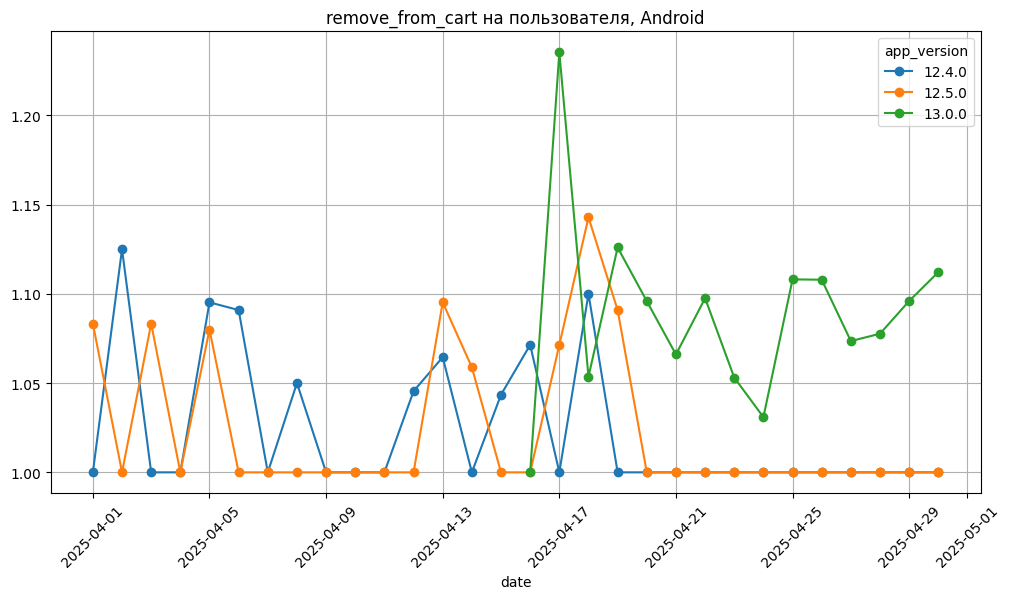

In [11]:
android = df[df['platform'] == 'Android']

for ev in android['event'].unique():
    sub = android[android['event'] == ev]
    events = sub.groupby(['date', 'app_version']).size()
    users = sub.groupby(['date', 'app_version'])['user_id'].nunique()
    ratio = (events / users).unstack()

    ratio.plot(figsize=(12, 6), marker='o', title=f'{ev} на пользователя, Android')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

а версии 13.0.0 событие add_to_favorites практически исчезает - среднее значение держится около 1.0 (то есть событие почти не повторяется у одного пользователя), а абсолютное число таких событий резко падает по сравнению с версиями 12.4.0 и 12.5.0. При этом остальные события (view_item, search, purchase) на 13.0.0 ведут себя так же, как на старых версиях.

Гипотеза: в релизе 13.0.0 сломалась или пропала кнопка/функционал «добавить в избранное» (например, из-за бага в UI или неудачного редизайна). Пользователи, которые раньше добавляли товар в избранное, чтобы вернуться к нему позже, теперь вынуждены использовать add_to_cart как замену - отсюда и рост числа добавлений в корзину без соответствующего роста покупок.

#### **6. Новости для команды — 1 балл**

На основе проведённого расследования подготовьте сообщение для команды о том, что именно пошло не так.

Что произошло: с 15-18 апреля выросла конверсия из просмотра в добавление в корзину, а конверсия из корзины в покупку - упала. Конверсия из просмотра в покупку в итоге почти не изменилась, то есть люди не стали покупать больше, просто воронка внутри перекосилась.

Где проблема: локализовали до Android-версии 13.0.0 (релиз вышел 15 апреля). На остальных платформах и версиях (iOS, старые Android 12.4.0/12.5.0) аномалий нет.

Что именно сломалось: в версии 13.0.0 практически исчезли события add_to_favorites - с ~4300 событий на версии 12.4.0 и ~3700 на 12.5.0 до 212 на 13.0.0, при сопоставимом числе пользователей. Похоже, в новом релизе сломалась или пропала кнопка «добавить в избранное». Пользователи, которым нужно было отложить товар, стали вместо неё нажимать «в корзину» - отсюда рост add_to_cart без роста покупок, и как следствие просадка конверсии cart - purchase.

Что предлагаю:

1. Проверить UI/логику кнопки избранного в релизе 13.0.0 - скорее всего баг или её убрали при редизайне.
2. Выкатить хотфикс и сравнить метрики до/после.
3. Дальше подключить автомониторинг воронки (view - cart - purchase) по срезам платформы/версии, чтобы не терять такие вещи на 2 недели.